In [2]:
import numpy as np
import matplotlib.pyplot as plt

from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from sklearn.linear_model import Lasso

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..',)))
from lib.utils.reservoirpy import *

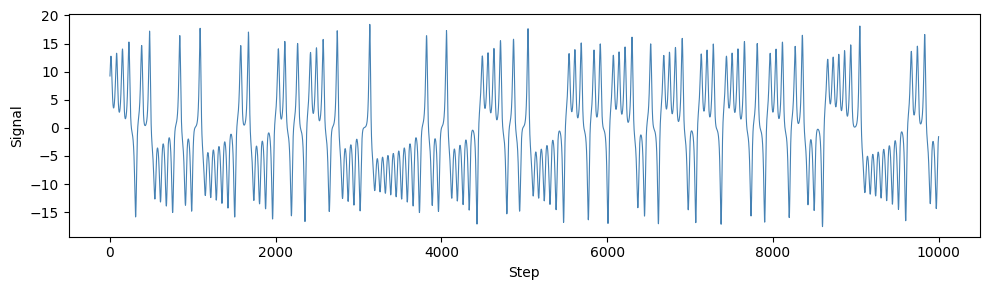

In [3]:
# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../data/chaotic_data/lorenz_system.csv', delimiter=',')
dataset = dataset[:, 0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.862e-01, tolerance: 2.999e-01
  model = cd_fast.enet_coordinate_descent(


Normalization      : zscore
Train interval     : [0 : 3000]
Test interval      : [3000 : 8000]
Train warmup       : 100
Test warmup        : 500
Prediction length  : 4500
Reservoir units    : 1500
Reservoir conn.    : 0.1
Spectral radius    : 1.2
Leak rate          : 0.1
Input scaling      : 1.0
Regression model   : lasso
Regression coef    : 1.00e-04
MSE                : 125.3606194944
RMSE               : 11.1964556666
NRMSE              : 1.4129226436


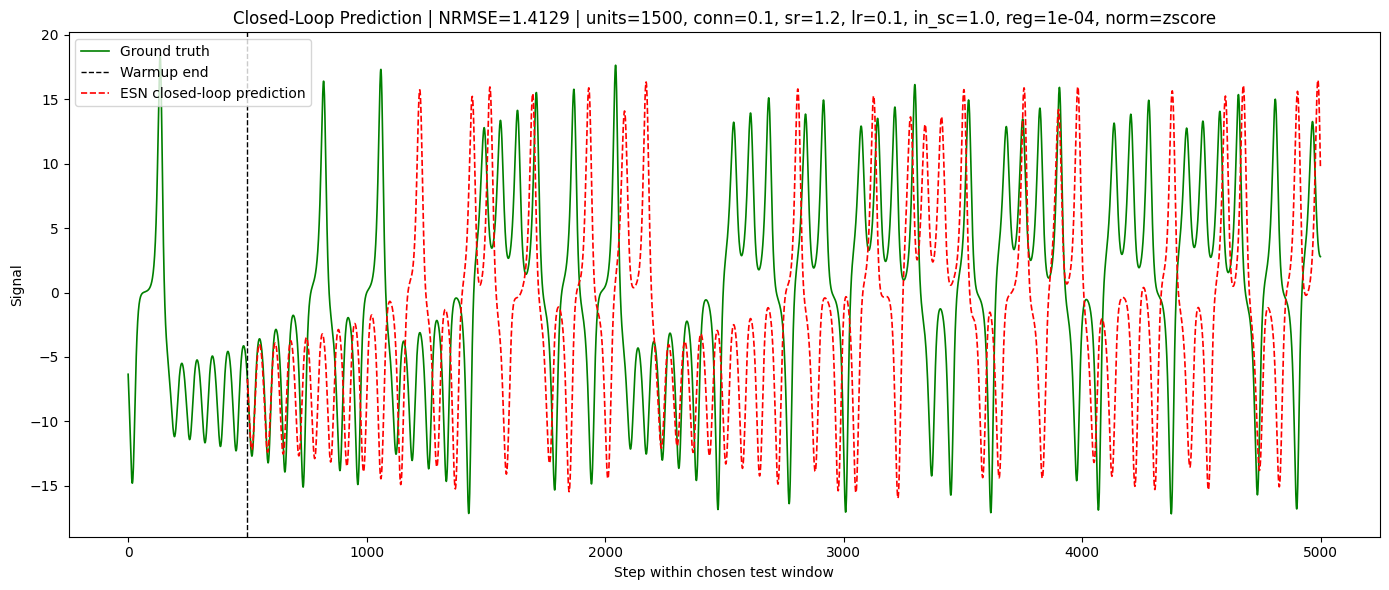

In [4]:
# ==========================================================
# PARAMETERS
# ==========================================================

# -------------------------
# Data split
# -------------------------
train_len = 3000
test_start = 3000
test_len = 5000

# -------------------------
# Warmups
# -------------------------
train_warmup = 100    # washout discarded during training
test_warmup = 500     # synchronization length before closed-loop rollout

# -------------------------
# Readout / regression
# -------------------------
regression = 1e-4
regression_model = "lasso"   # "ridge" or "lasso"

# -------------------------
# Reservoir hyperparameters
# -------------------------
res_units = 1500
leak_rate = 0.1
spectral_rad = 1.2
input_scaling = 1.0
reservoir_connectivity = 0.1
input_connectivity = 1.0
bias_connectivity = 1.0
seed = 42

# -------------------------
# Data normalization
# Options:
#   "none"
#   "zscore"
#   "minmax01"
#   "minmax11"
# -------------------------
normalization = "zscore"


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)

# one-step supervised pairs
X_raw = data[:-1]
Y_raw = data[1:]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]

X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]

# Fit normalization only on training input data
scaler = fit_scaler(X_train_raw, method=normalization)

# Transform all sets consistently
X_train = transform_array(X_train_raw, scaler)
Y_train = transform_array(Y_train_raw, scaler)

X_test = transform_array(X_test_raw, scaler)
Y_test = transform_array(Y_test_raw, scaler)

# Safety check
if test_warmup >= test_len:
    raise ValueError("test_warmup must be smaller than test_len.")


# ==========================================================
# ESN DEFINITION
# ==========================================================
reservoir = Reservoir(
    units=res_units,
    lr=leak_rate,
    W=uniform(
        low=-0.5,
        high=0.5,
        connectivity=reservoir_connectivity,
        sr=spectral_rad
    ),
    Win=uniform(
        low=-0.5 * input_scaling,
        high=0.5 * input_scaling,
        connectivity=input_connectivity
    ),
    bias=uniform(
        low=-0.5,
        high=0.5,
        connectivity=bias_connectivity
    ),
    activation="tanh",
    seed=seed
)

if regression_model == "ridge":
    readout = Ridge(ridge=regression)
elif regression_model == "lasso":
    readout = ScikitLearnNode(model=Lasso, alpha=regression, max_iter=10000)
else:
    raise ValueError("regression_model must be 'ridge' or 'lasso'.")

esn = reservoir >> readout


# ==========================================================
# TRAINING
# ==========================================================
esn.fit(X_train, Y_train, warmup=train_warmup)


# ==========================================================
# TESTING
# ==========================================================
esn.reset()

# synchronize reservoir with true test input
if test_warmup > 0:
    esn.run(X_test[:test_warmup])

pred_len = test_len - test_warmup
Y_pred_scaled = []

# seed for first autonomous step
current_input = X_test[test_warmup:test_warmup + 1]

for _ in range(pred_len):
    pred = esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred_scaled.append(pred[0, 0])

    # closed-loop feedback
    current_input = pred

Y_pred_scaled = np.array(Y_pred_scaled).reshape(-1, 1)
Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len]

# invert scaling for metrics in original units
Y_pred = inverse_transform_array(Y_pred_scaled, scaler).ravel()
Y_true = inverse_transform_array(Y_true_scaled, scaler).ravel()

Y_test_original = Y_test_raw.ravel()


# ==========================================================
# ERROR METRICS
# ==========================================================
mse = np.mean((Y_true - Y_pred) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)

print(f"Normalization      : {normalization}")
print(f"Train interval     : [0 : {train_len}]")
print(f"Test interval      : [{test_start} : {test_start + test_len}]")
print(f"Train warmup       : {train_warmup}")
print(f"Test warmup        : {test_warmup}")
print(f"Prediction length  : {pred_len}")
print(f"Reservoir units    : {res_units}")
print(f"Reservoir conn.    : {reservoir_connectivity}")
print(f"Spectral radius    : {spectral_rad}")
print(f"Leak rate          : {leak_rate}")
print(f"Input scaling      : {input_scaling}")
print(f"Regression model   : {regression_model}")
print(f"Regression coef    : {regression:.2e}")
print(f"MSE                : {mse:.10f}")
print(f"RMSE               : {rmse:.10f}")
print(f"NRMSE              : {nrmse:.10f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    np.arange(test_len),
    Y_test_original,
    c='green',
    linewidth=1.2,
    label="Ground truth"
)

ax.axvline(
    test_warmup,
    linestyle="--",
    c='k',
    linewidth=1.0,
    label="Warmup end"
)

ax.plot(
    np.arange(test_warmup, test_warmup + pred_len),
    Y_pred,
    linestyle="--",
    c='red',
    linewidth=1.2,
    label="ESN closed-loop prediction"
)

ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={res_units}, conn={reservoir_connectivity}, "
    f"sr={spectral_rad}, lr={leak_rate}, "
    f"in_sc={input_scaling}, reg={regression:.0e}, "
    f"norm={normalization}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()

plt.tight_layout()
plt.show()